# Response to Reviewers
This notebook includes all of the figures and analysis included in the response to reviewers document. 

1. Done - Autocorrelation plots of SIA anomalies initialized during each month
2. Two - calculate ASL time series 2023 and ENSO less time series 2023
3. Download 2024 sea ice concentration, process, and plot anomalies compared with individual ensemble members
4. Create RMSE per sector of 2023 forecast members!


In [1]:
import os
import csv
import sys
import pandas as pd
import numpy as np
import xarray as xr

import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature
import cartopy.util as cutil
import cmocean
import matplotlib as mpl
import matplotlib.animation as animation
import matplotlib.path as mpath
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable

from scipy.stats import linregress
SEASON = "QS-DEC"

/glade/work/zespinosa/conda-envs/cenv/lib/python3.8/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.31.0 or higher is recommended. You are running version 2.27.0
  warnings.warn(
ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/zespinosa/conda-envs/cenv/share/proj failed


In [2]:
cdict2 = [
    (36,   0, 216),
    (24,  28, 247),
    (40,  87, 255),
    (61, 135, 255),
    (86, 176, 255),
    (117, 211, 255),
    (153, 234, 255),
    (188, 249, 255),
    (234, 255, 255),
    (255, 255, 234),
    (255, 241, 188),
    (255, 214, 153),
    (255, 172, 117),
    (255, 120,  86),
    (255,  61,  61),
    (247,  39,  53),
    (216,  21,  47),
    (165,   0,  33),
]
# Convert to 0 to 1
cdict2 = [(r/255, g/255, b/255) for i, (r, g, b) in enumerate(cdict2)]
mpl.colormaps.register(LinearSegmentedColormap.from_list('BWYR', cdict2))

# Figure R1 - autocorrelation of SIA Anomalies 

In [3]:
si_nsidc = xr.open_dataset("/glade/work/zespinosa/Projects/SI-Antarctic/data/si_NSIDC_SH_anoms.nc").sie.sel(time=slice('1979-01-01', '2022-12-31'))
# Get time series of september from monthly time series
si_nsidc_sept = si_nsidc.sel(time=si_nsidc['time.month']==9)
si_nsidc_dec = si_nsidc.sel(time=si_nsidc['time.month']==12)
si_nsidc_jan = si_nsidc.sel(time=si_nsidc['time.month']==1)

def get_autocorrelation_function(si_nsidc_init, idx):
    init_time = si_nsidc_init.isel(time=0)
    acf = []

    for month in np.arange(1,13):
        si_nsidc_month = si_nsidc.sel(time=si_nsidc['time.month']==month)
        si_nsidc_month = si_nsidc_month.sel(time=slice(init_time.time, None))
        si_nsidc_truth = si_nsidc_init.isel(time=slice(0, np.size(si_nsidc_month.time)))

        si_nsidc_truth = si_nsidc_truth[~np.isnan(si_nsidc_month.values)]
        si_nsidc_month = si_nsidc_month[~np.isnan(si_nsidc_month.values)]
        si_nsidc_month = si_nsidc_month[~np.isnan(si_nsidc_truth.values)]
        si_nsidc_truth = si_nsidc_truth[~np.isnan(si_nsidc_truth.values)]

        reg = linregress(si_nsidc_month.values, si_nsidc_truth.values)
        acf.append(reg.rvalue**2)

    acf = np.roll(np.array(acf), idx)
    coords = np.roll(np.arange(1,13), idx)
    return xr.DataArray(acf, dims='month', name="acf", coords={'month': coords})

sept_r = get_autocorrelation_function(si_nsidc_sept, -8)
dec_r = get_autocorrelation_function(si_nsidc_dec, -11)
jan_r = get_autocorrelation_function(si_nsidc_jan, 0)

dec_jja = np.around(dec_r.sel(month=[6,7,8]).mean("month").values, 3)
jan_jja = np.around(jan_r.sel(month=[6,7,8]).mean("month").values, 3)
sept_jja = np.around(sept_r.sel(month=[6,7,8]).mean("month").values, 3)

sept_r["month"] = np.arange(1,13)

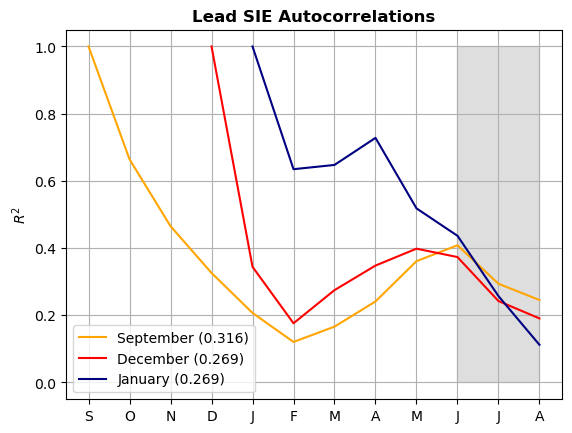

In [5]:
plt.plot(sept_r.month, sept_r, label=f'September ({sept_jja})', color="orange")
plt.plot(np.arange(4, 13), dec_r.isel(month=slice(0,9)), label=f'December ({dec_jja})', color="red")
plt.plot(np.arange(5, 13), jan_r.isel(month=slice(0,8)), label=f'January ({jan_jja})', color="navy")
plt.legend(loc='lower left')

# Add light shading between two veritcal lines at 9 and 12
plt.fill_betweenx(y=[0, 1], x1=10, x2=12, color='lightgrey', alpha=0.75)

plt.grid()
labels = ['S', 'O', 'N', 'D', 'J', 'F', 'M', 'A', 'M', 'J', 'J', 'A']
# labels = ['Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug']
plt.xticks(ticks=sept_r.month, labels=labels)
plt.ylabel(r"$R^2$")
plt.title("Lead SIE Autocorrelations", fontweight='bold')
plt.savefig("figures/lead_sie_autocorrelations.png", dpi=400)

# Figure SX - ASL timeseries ENSO-Less

In [21]:
sys.path.insert(0, "/glade/work/zespinosa/Projects/climate-utils")
from utils import (
    from_pickle, 
    to_pickle, 
    xarray_time_to_monthly,
    xarray_monthly_to_time,
    get_season,
)

def read_csv(ds, fp, len_header): 
    index = []
    with open(fp, newline='') as csvfile:
        csvf = csv.reader(csvfile, delimiter=' ', quotechar='|')
        for i, row in enumerate(csvf):
            if i < len_header: continue
            if i == len_header: 
                header = row[0].split(',')
                continue
                
            ds[i-(len_header+1), :] = row[0].split(',')[1:]
            index.append(row[0].split(',')[0])
    
    ds = pd.DataFrame(data=ds, index=np.array(index), columns=header[1:])
    return ds
        
def read_txt(ds, fp, len_header, fill=-99.99):
    """
    Read arbitrary text file with header and data delineated with a space
    """
    nyrs, nmons = ds.shape
    years = []
    
    with open(fp) as f:
        lines = f.readlines()
        for n, line in enumerate(lines):
            if n < len_header: continue # skip header
            if n >= (nyrs+len_header): break # skip footer
            
            cidx = line.split()
            years.append(int(cidx[0]))
            ds[n-len_header, :] = cidx[1:]
            
    ds = xr.DataArray(
        data=ds,
        dims=["year", "month"],
        coords=dict(year=years, month=np.arange(1, 1+nmons))
    )
    ds = ds.where(fill, np.nan)

    return ds


ROOT = "/glade/work/zespinosa/data/index/"

# Load IPO, SAM, NINO 3.4
ipo = read_txt(np.zeros((2024 - 1854, 12)), os.path.join(ROOT, "IPO-TPI_NOAA-ERSSTV5_185401-202312_monthly.txt"), len_header=2)
nino34 = read_txt(np.zeros((2024 - 1948, 12)), os.path.join(ROOT, "ENSO", "Nino34_194801-202309_anoms.txt"), len_header=2)
sam_marshall = read_txt(np.zeros((2024 - 1957, 12)), os.path.join(ROOT, "SAM", "SAM_Marshall-195701-202311_monthly.txt"), len_header=4)

# Load ASL index
asl = read_csv(np.zeros((538, 5)), os.path.join(ROOT, "ASL/amundsen-sea-low-index/v3/era5", "asli_monthly_v3.20210820-era5-197901-202312.csv"), len_header=26)
asl = xr.DataArray(asl, dims=['time', 'index']) #.sel(index="ActCenPres")
asl["time"] = np.array(asl.time.values, dtype="datetime64[M]")

In [22]:
# Prep IPO
TIME_RANGE = slice("1980-01", "2023-9")

ipo_flat = xarray_monthly_to_time(ipo)
ipo_flat = ipo_flat.sel(time=TIME_RANGE)
# Prep NINO 3.4
nino34_flat = xarray_monthly_to_time(nino34)
nino34_flat = nino34_flat.sel(time=TIME_RANGE)
nino34_flat = nino34_flat.where(nino34_flat != -99.99, np.nan) # fill -99.99 with nan
# Prep SAM
sam_flat = xarray_monthly_to_time(sam_marshall)
sam_flat = sam_flat.sel(time=TIME_RANGE)

In [23]:
# Standardize Each Term
idx = "RelCenPres"
time_slice = slice("1980-01", "2023-10")

asl_z = (asl.sel(index=idx) - asl.sel(index=idx, time=time_slice).mean()) / asl.sel(index=idx, time=time_slice).std()
ipo_z = (ipo_flat - ipo_flat.sel(time=time_slice).mean())/ ipo_flat.sel(time=time_slice).std()
nino34_z = (nino34_flat - nino34_flat.sel(time=time_slice).mean())/ nino34_flat.sel(time=time_slice).std()
sam_z = (sam_flat - sam_flat.sel(time=time_slice).mean())/ sam_flat.sel(time=time_slice).std()

asl_lat = (asl.sel(index='lat') - asl.sel(index='lat', time=time_slice).mean()) / asl.sel(index='lat', time=time_slice).std()
asl_lon = (asl.sel(index='lon') - asl.sel(index='lon', time=time_slice).mean()) / asl.sel(index='lon', time=time_slice).std()

In [24]:
asl_z

<xarray.DataArray (time: 538)>
array([ 1.91438803e+00, -1.20314005e-01,  3.19682355e-01, -8.79687471e-01,
       -2.62086763e-01, -4.77508650e-01,  5.87297775e-01, -2.27833308e+00,
        2.64017849e-02, -4.06168886e-01,  4.98042251e-01,  7.37639870e-01,
        1.66255148e+00,  1.07905571e+00,  9.46802140e-01,  1.18981522e-01,
        3.56830743e-01, -4.41914539e-01, -1.09510918e+00,  8.26830676e-01,
        4.85483520e-02, -3.80093922e-01, -3.61141919e-01,  1.42129175e+00,
        8.15455159e-01,  3.09688284e-01, -1.26779242e+00,  1.23965086e+00,
       -7.48552251e-02, -1.03322420e+00, -2.38731404e-01, -1.49199963e+00,
        1.37026755e-01,  1.60066615e+00,  5.26060053e-01,  2.93866266e-01,
        1.23934870e+00,  1.29190908e+00,  6.01954218e-01, -1.25453886e+00,
        8.80993729e-03, -1.61542014e-01,  1.19024668e-01, -2.95643757e+00,
       -1.12742262e+00,  5.84993121e-02, -6.13928313e-01, -8.37509546e-01,
       -3.54320980e-01,  2.93089145e-01,  3.70321611e-01, -1.81444186e+00,
        1.10110093e-01,  1.18247689e-01, -8.46118520e-02, -3.82619371e-01,
        1.06526863e-01, -1.38301491e+00,  9.06615582e-02,  6.99520098e-01,
       -7.32432004e-01,  9.01710347e-01,  3.06795883e-01,  1.19594048e+00,
       -9.52101772e-02, -4.32006548e-01, -1.50467001e+00, -1.11669485e+00,
       -1.15859198e+00, -1.08891421e+00,  1.56125132e+00,  7.05434443e-01,
        1.48447217e+00,  1.40635472e+00,  2.95528266e-01,  8.77772165e-01,
       -3.77066241e-02, -1.13797779e+00, -1.62388632e+00, -4.84545496e-01,
...
       -6.48572685e-01, -5.74060107e-01,  7.53893630e-01, -1.57240515e+00,
       -2.05382368e+00,  5.77260559e-01, -9.78434904e-02, -1.41596947e-01,
       -1.05247252e-01,  4.70218677e-01,  6.31185735e-02, -8.33814872e-02,
       -8.07909662e-02, -6.02617374e-01,  2.12813197e-01,  1.39255531e-02,
       -1.01340428e-01, -1.40675893e+00,  1.35364932e-01,  8.39738720e-01,
        9.79633501e-01,  1.80598627e+00,  8.43926240e-01, -8.50050497e-01,
       -1.19882193e-01, -1.58578816e+00, -7.43371209e-02, -1.75911859e+00,
       -1.65777529e+00,  5.05553948e-01,  1.39685715e+00,  2.54306490e-02,
        6.45966798e-01,  7.64081963e-01, -4.18580753e-01,  2.53350518e-01,
        1.04950978e-01, -1.41871706e+00, -1.76893993e+00, -8.13894958e-01,
        9.55587383e-01, -3.29756829e-01, -9.66287968e-01,  1.77693867e-01,
        9.04889747e-02, -1.18084641e+00, -6.64524282e-01,  3.62486107e-01,
        1.08438731e+00,  1.35368865e-02, -1.53404418e-01, -1.83753299e-01,
       -3.70747535e-01, -1.80138280e+00, -1.71579089e-01,  1.24313221e-01,
        4.63570321e-01, -1.17097692e-01, -6.75252399e-01,  2.76252492e-01,
       -3.55184251e-01, -7.19626830e-02, -1.83378218e+00, -1.19420784e+00,
        5.78515935e-02, -3.77395537e-01, -1.80764249e+00,  1.10407314e+00,
        1.57619363e-01, -3.38952206e-01, -1.99802545e+00,  9.89070184e-02,
        1.53863550e-01,  3.65637560e-01, -5.89882267e-01, -1.51093006e+00,
       -2.82932132e+00,  6.37332636e-01])
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2023-10-01
    index    <U10 'RelCenPres'

In [25]:
asl_z = asl_z.sel(time=TIME_RANGE)

reg = linregress(nino34_z.values, asl_z.sel(time=TIME_RANGE).values)
print(reg)

asl_z_month_no_enso_all = np.zeros((12, 44))
for i in range(0, 12):
    # select all of the months
    asl_z_month = asl_z.sel(time=asl_z['time.month']==i+1)
    nino34_z_month = nino34_z.sel(time=nino34_z['time.month']==i+1)
    reg = linregress(nino34_z_month.values, asl_z_month.values)
    asl_z_month_no_enso = asl_z_month - (reg.slope * nino34_z_month + reg.intercept)
    asl_z_month_no_enso_all[i, :len(asl_z_month_no_enso)] = asl_z_month_no_enso

# Create xarray DataArray with year and month as dims
asl_z_month_no_enso_all = xr.DataArray(asl_z_month_no_enso_all, dims=['month', 'year'], coords={'month': np.arange(1,13), 'year': np.arange(1980, 2024)})
# Convert from year and month to time
asl_z_month_no_enso_all = xarray_monthly_to_time(asl_z_month_no_enso_all)
asl_z_no_enso = asl_z_month_no_enso_all

LinregressResult(slope=-0.04632333803096093, intercept=-0.001213966924860574, rvalue=-0.04629719704464854, pvalue=0.28967201900720435, stderr=0.04370472223137112, intercept_stderr=0.043704722231371104)


In [26]:
asl_z_2023 = asl_z.sel(time=slice("2023-01", "2023-09"))
asl_z_no_enso_2023 = asl_z_no_enso.sel(time=slice("2023-01", "2023-09"))

# Get average index for JJA
asl_z_2023_jja = asl_z_2023.sel(time=asl_z_2023['time.month'].isin([6,7,8])).mean("time")
asl_z_no_enso_2023_jja = asl_z_no_enso_2023.sel(time=asl_z_no_enso_2023['time.month'].isin([6,7,8])).mean("time")
print(asl_z_2023_jja, asl_z_no_enso_2023_jja)

<xarray.DataArray ()>
array(-0.57839159)
Coordinates:
    index    <U10 'RelCenPres' <xarray.DataArray ()>
array(-0.0811805)


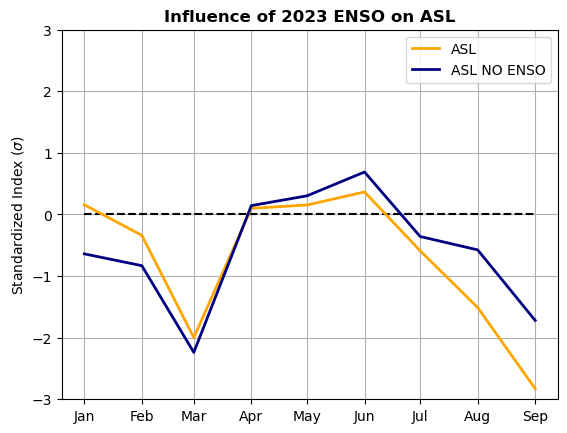

In [30]:
plt.hlines(0, asl_z_2023.time[0], asl_z_2023.time[-1], color='black', linestyle='--')
plt.plot(asl_z_2023.time, asl_z_2023, linewidth=2, label="ASL", color="orange")
plt.plot(asl_z_2023.time, asl_z_no_enso_2023, linewidth=2, label="ASL NO ENSO", color="navy")
plt.xticks(asl_z_2023.time.values, labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep"])
plt.grid()
plt.ylim(-3, 3)
plt.ylabel(r"Standardized Index ($\sigma$)")
plt.title("Influence of 2023 ENSO on ASL", fontweight="bold")
plt.legend()
plt.savefig("figures/asl_enso_influence.png", dpi=400)

# Forecast 2024 Evaluation 
1980 Plot Individual Member with Integrated Extent 

In [3]:
def plot_stationary_sp(nplots: int = 3, minLon: int = -180, maxLon: int = 180, nrows: int = 1, figsize: list = [20, 20]):
    """
    TODO: Add Doc String
    Create a stationary centered on south pole (Longitude: [minLon,maxLon]; Latitude: [-90,-60]
    Returns:
        ax, fig
    """
    # Create subplots
    if nplots == 3:
        figsize = [20, 20]
    if nplots == 2:
        figsize = [10, 10]
    if nplots == 1:
        figsize = [5, 5]

    fig, axs = plt.subplots(nrows=nrows, ncols=nplots, figsize=figsize, subplot_kw=dict(projection=ccrs.SouthPolarStereo()))
    fig.subplots_adjust(bottom=0.05, top=0.95, left=0.04, right=0.95, wspace=0.15)

    # Compute a circle in axes coordinates, which we can use as a boundary
    # for the map. We can pan/zoom as much as we like - the boundary will be
    # permanently circular.
    theta = np.linspace(0, 2 * np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    
    if nplots == 1:
        axs =  [axs]

    # Add properties to axes
    for ax in axs.flatten():
        # Limit the map to -60 degrees latitude and below.
        ax.set_extent([minLon, maxLon, -90, -50], ccrs.PlateCarree())

        gl = ax.gridlines(draw_labels=True, color="gray", rotate_labels=False, linestyle="dashed", zorder=4)
        # ax.tick_params(which="both", zorder=103)

        ax.add_feature(cartopy.feature.LAND, facecolor="grey", edgecolor="black", zorder=3)
        ax.add_feature(cartopy.feature.OCEAN, facecolor="white")


        ax.set_boundary(circle, transform=ax.transAxes)

        # No label_artist if not run `plt.draw()`
        plt.draw() 

        # Reposition the tick labels
        for ea in gl.label_artists:
            pos = ea.get_position()
            if (pos[0]==150):
                ea.set_position([310, pos[1]])
                if pos[1] not in [-75, -65, -55]: 
                    ea.set_visible(False)


    return fig, axs

def interpolate_seaice_gap(ds):
    """
    There is an issue in the sea ice data at longitude 319.5 and 320.5 (indices 319 and 320).
    This function fills the gap by taking linear interpolation between the two points on 
    either side of the gap (indices 318 and 321).
    """
    ds[:, 319] = ds[:, 318] + (ds[:, 321] - ds[:, 318])/3
    ds[:, 320] = ds[:, 318] + (ds[:, 321] - ds[:, 318])*2/3
    return ds


def spatial_obs_plot(dfs, cmap_info, save_info):
    fig, axes = plot_stationary_sp(nplots=len(dfs.keys()))

    for i, ((key, ds), ax) in enumerate(zip(dfs.items(), axes)):

        if not cmap_info["shared"]:
            levels = cmap_info["levels"][i]
            units = cmap_info["units"][i]
            cmap = cmap_info["cmap"][i]
        else: 
            levels = cmap_info["levels"]
            units = cmap_info["units"]
            cmap = cmap_info["cmap"]

        # Create contour plot
        dsi = interpolate_seaice_gap(ds["ds"].values)
        img = ax.contourf(
            ds["ds"].lon.values,
            ds["ds"].lat.values,
            # ds["ds"].values,
            dsi,
            transform=ccrs.PlateCarree(), 
            levels=levels,
            extend="both",
            cmap=cmap,
        )
        
        # Add ice edge
        if "edge" in ds.keys():
            dsi = interpolate_seaice_gap(ds["edge"].values)
            ax.contour(
                ds["edge"].lon.values,
                ds["edge"].lat.values,
                dsi,
                transform=ccrs.PlateCarree(), 
                levels=[.15],
                colors="yellow"
            )
    
        if "edge_clim" in ds.keys():
            dsi = interpolate_seaice_gap(ds["edge_clim"].values)
            ax.contour(
                ds["edge_clim"].lon.values,
                ds["edge_clim"].lat.values,
                ds["edge_clim"].values,
                transform=ccrs.PlateCarree(), 
                levels=[.15],
                colors="magenta",
            )

        if key.split("_")[-1] == "siconc":
            if "edge_ens" in ds.keys():
                ax.contour(
                    ds["edge_ens"].lon.values,
                    ds["edge_ens"].lat.values,
                    ds["edge_ens"].values,
                    transform=ccrs.PlateCarree(), 
                    levels=[.15],
                    colors="black",
                )

        # Plot Winds if given
        if "wind" in ds.keys():
            lat_step, lon_step = 5, 5 
            # Add quivers
            Q = ax.quiver(
                x=ds["wind"][0].lon[::lon_step],
                y=ds["wind"][0].lat[::lat_step],
                u=ds["wind"][0].values[::lat_step, ::lon_step], 
                v=ds["wind"][1].values[::lat_step, ::lon_step], 
                color="black", 
                scale=ds["wind"][2],
                transform=ccrs.PlateCarree(),
            )
            # Add quiver key
            if i == (len(axes) - 1):
                qk = ax.quiverkey(Q, .9, .05, ds["wind"][-1], str(ds["wind"][-1]) + r' $\frac{m}{s}$', labelpos='E',
                    transform=ccrs.PlateCarree(), coordinates='axes')

        if "include_regions" in ds.keys():
            regional_bounds = {
                "ross": (155, 215, "ROSS"),
                "amundsen": (215, 255, "AM"),
                "bellingshausen": (255, 295, "BS"),
                "weddell": (295, 360, "WE"),
                "south_indian": (0, 75, "SI"),
                "south_west_pacific": (75, 155, "SWP"),
            }

            lat_min, lat_max = -90, -40
            for region, bounds in regional_bounds.items():
                ax.plot(
                    [bounds[0], bounds[0]], 
                    [lat_max, lat_min], 
                    color="black", linewidth=2, linestyle="solid", transform=ccrs.PlateCarree(), zorder=10
                )
                ax.text(
                    (bounds[0]+ bounds[1])/2,
                    -57,
                    bounds[-1],
                    fontsize=12,
                    color="black",
                    fontweight="bold",
                    transform=ccrs.PlateCarree()
                )

        if not cmap_info["shared"]:
            cbar = plt.colorbar(img, ax=ax, orientation="vertical", fraction=.046, pad=0.06)
            cbar.ax.set_title(units)
            if "ticks" in cmap_info.keys():
                cbar.set_ticks(cmap_info["ticks"])
                cbar.set_ticklabels(cmap_info["ticks"])

        # Set properties
        if "title" in ds.keys():
            ax.set_title(ds["title"], loc="right", fontweight="bold", fontsize=16)

        if "left_title" in ds.keys():
            ax.set_title(ds["left_title"], loc="left", fontweight="bold", fontsize=16)

    if len(dfs) >= 4: 
        fraction = .012
    if len(dfs) == 3: 
        fraction = .016
    elif len(dfs) == 2: 
        fraction = .026

    if cmap_info["shared"]:
        cbar = fig.colorbar(img, ax=axes.ravel().tolist(), orientation="vertical", fraction=fraction, pad=0.04)
        cbar.ax.set_title(cmap_info["units"])
        if "ticks" in cmap_info.keys():
            cbar.set_ticks(cmap_info["ticks"])
            cbar.set_ticklabels(cmap_info["ticks"])

    if save_info["save"]:
        plt.savefig(save_info["path"] + ".pdf", dpi=save_info["dpi"], bbox_inches="tight")
        plt.savefig(save_info["path"] + ".png", dpi=save_info["dpi"], bbox_inches="tight")


In [4]:
ENSEMBLE_MEMBERS = ["1980", "1985", "1989", "1990", "1993", "1994", "1998", "1999", "2000", "2003", "2004", "2005", "2006", "2007", "2009", "2012", "2013", "2014", "2018", "2020", "2021"]

def load_ensemble(file_name, ens_mems, drop_vars=[], include_year=False, ensemble: str = "persistence_ensemble"):
    """
    Load the processed data files for each ensemble member and return a concatenated dataset.
    """
    ens = []
    for mem in ens_mems: 
        try:
            if include_year:
                path = f"../data/{ensemble}/{mem}/{mem}{file_name}"
            else:
                path = f"../data/{ensemble}/{mem}/{file_name}"

            cesm2_ens = xr.open_dataset(
                path,
                chunks="auto", 
                drop_variables=drop_vars
            )
            ens.append(cesm2_ens)
        except Exception as e:
            print(f"Could not load {mem}")
            print(e)

    ens = xr.concat(ens, pd.Index([int(yr) for yr in ENSEMBLE_MEMBERS], name="year"))

    return ens

In [5]:
# Load SIA/SIE
si_cesm2_ice_ens_2024 = load_ensemble(file_name=f"si_CESM_SH_anoms.nc", ens_mems=ENSEMBLE_MEMBERS, ensemble="forecast_ensemble")

# Load SIC
cesm2_ice_ens_anoms = load_ensemble(file_name=f"_cesm2_ice_monthly_1950-01_2024-12-anoms.nc", ens_mems=ENSEMBLE_MEMBERS, include_year=True, ensemble="forecast_ensemble")
cesm2_ice_ens = load_ensemble(file_name=f"_cesm2_ice_monthly_1950-01_2024-12-regrid.nc", ens_mems=ENSEMBLE_MEMBERS, include_year=True, ensemble="forecast_ensemble")
cesm2_ice_clim = xr.open_dataset("../data/cesm2_ice_monthly_1950-01_2023-12-clim.nc")

/glade/work/zespinosa/conda-envs/cenv/lib/python3.8/site-packages/xarray/coding/times.py:682: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/glade/work/zespinosa/conda-envs/cenv/lib/python3.8/site-packages/xarray/core/indexing.py:524: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(array[self.key], dtype=None)


In [6]:
MEM_YEAR = 1998
TIME = "2024-06"
print(si_cesm2_ice_ens_2024.resample(time=SEASON).mean(dim="time").sel(year=MEM_YEAR).sel(time=TIME).sie.values)
print(si_cesm2_ice_ens_2024.sel(year=MEM_YEAR).sel(time=TIME).sie.values)
# vs. -1.685 currently

[-2.06970919]
[-1.98329262]


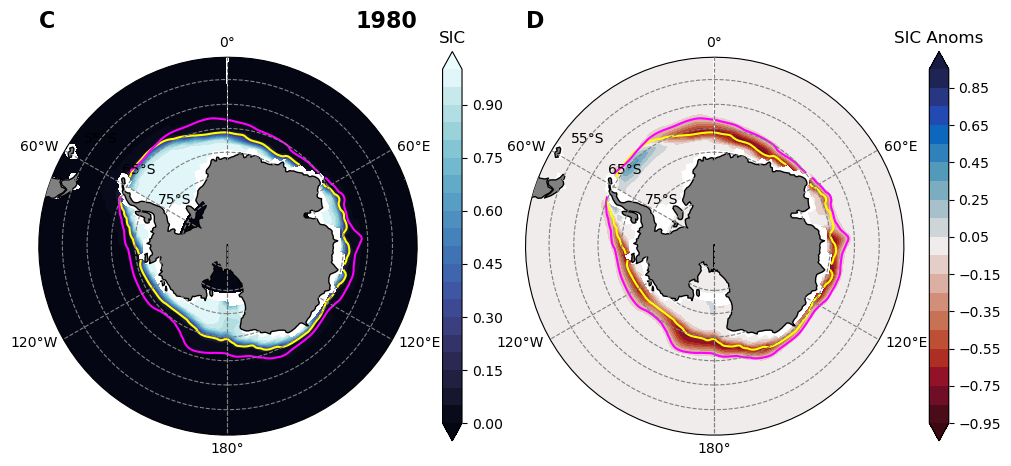

In [7]:
TIME = "2024-06"
MEM_YEAR = 1980
SEASON = "QS-DEC"

save_info = {
    "save": True,
    "path": "figures/Figure_2024_comparison_1980_june",
    "dpi": 400,
}

cmap_info = {
    "cmap": [cmocean.cm.ice, cmocean.cm.balance_r], 
    "units": ["SIC", "SIC Anoms"],
    "shared": False,
    "levels": [np.arange(0, 1.05, .05), np.arange(-.95, 1.05, .1)],
}
# resample(time=SEASON).mean(dim="time").
cesm2_forecast_2024_mem = {
    "ds": cesm2_ice_ens["aice"].sel(time=TIME).sel(year=MEM_YEAR).squeeze(),
    "edge": cesm2_ice_ens["aice"].sel(time=TIME).sel(year=MEM_YEAR).squeeze(),
    "edge_clim": cesm2_ice_clim["aice"].isel(time=5).squeeze(), # June
    "left_title": "C",
    "title": "1980",
}

SEASON_ENS = slice("2023-10", "2023-11")

cesm2_forecast_2024_mem_anoms = {
    "ds": cesm2_ice_ens_anoms["aice"].sel(time=TIME).sel(year=MEM_YEAR).squeeze(),
    "edge": cesm2_ice_ens["aice"].sel(time=TIME).sel(year=MEM_YEAR).squeeze(),
    "edge_clim": cesm2_ice_clim["aice"].isel(time=5).squeeze(), # June
    "left_title": "D",
    "title": "",
}


spatial_obs_plot(
    dfs={
        "cesm2_forecast_ice": cesm2_forecast_2024_mem,
        "cesm2_forecast_ice_anoms": cesm2_forecast_2024_mem_anoms,
    }, 
    cmap_info=cmap_info,
    save_info=save_info,
)

In [6]:
# nsidc_ice_anoms = xr.open_dataset("/glade/work/zespinosa/Projects/SI-Antarctic/data/nsidc_regrid_realtime-anoms.nc")["cdr_seaice_conc"]
# nsidc_ice_anoms = nsidc_ice_anoms.transpose("time", "lat", "lon")

# nsidc_ice = xr.open_dataset("/glade/work/zespinosa/Projects/SI-Antarctic/data/nsidc_regrid_realtime.nc")["cdr_seaice_conc"]
# nsidc_ice = nsidc_ice.transpose("time", "lat", "lon")
# nsidc_ice

nsidc_ice_anoms = xr.open_dataset("/glade/work/zespinosa/Projects/SI-Antarctic/data/nsidc_regrid_realtime_2024jja-anoms.nc")["cdr_seaice_conc"]
nsidc_ice_anoms = nsidc_ice_anoms.transpose("time", "lat", "lon")

nsidc_ice = xr.open_dataset("/glade/work/zespinosa/Projects/SI-Antarctic/data/nsidc_regrid_realtime_2024jja.nc")["cdr_seaice_conc"]
# nsidc_ice = nsidc_ice.transpose("time", "lat", "lon")


nsidc_ice_clim = xr.open_dataset("/glade/work/zespinosa/Projects/SI-Antarctic/data/nsidc_regrid_realtime_2024jja-clim.nc")["cdr_seaice_conc"]
# nsidc_ice_c= nsidc_ice.transpose("time", "lat", "lon")
# nsidc_ice_clim
# xr.open_dataset("/glade/work/zespinosa/Projects/SI-Antarctic/data/si_NSIDC_SH_anoms_realtime.nc")

/glade/work/zespinosa/conda-envs/cenv/lib/python3.8/site-packages/xarray/coding/times.py:682: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/glade/work/zespinosa/conda-envs/cenv/lib/python3.8/site-packages/xarray/core/indexing.py:524: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(array[self.key], dtype=None)


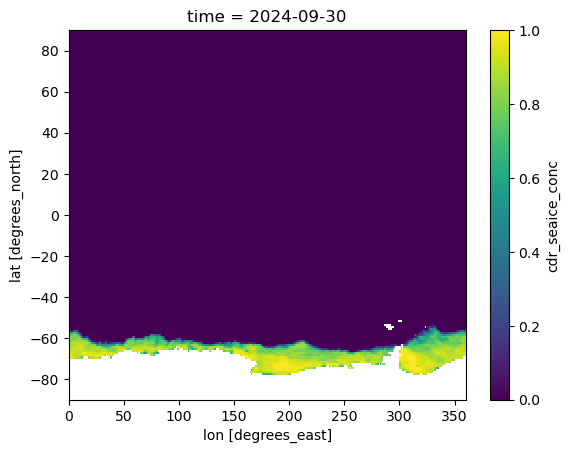

In [7]:
# nsidc_ice = xr.open_dataset("/glade/work/zespinosa/Projects/SI-Antarctic/data/nsidc_regrid_realtime.nc")["cdr_seaice_conc"]
nsidc_ice.isel(time=-1).plot()

In [24]:
si_cesm2_ice_ens_2024
si_obs_ice = xr.open_dataset("/glade/work/zespinosa/Projects/SI-Antarctic/data/si_NSIDC_SH_anoms_realtime.nc")
si_obs_ice_clim = xr.open_dataset("/glade/work/zespinosa/Projects/SI-Antarctic/data/si_NSIDC_SH_si.nc").sel(time=slice("1980-01", "2020-12")).groupby("time.month").mean("time") #.sel(month=6) # .sie.values
print(si_obs_ice_clim.sie.values)
obs_sie_june = si_obs_ice.sel(time="2024-06").sie.values - si_obs_ice_clim.sie.values 
obs_sia_june = si_obs_ice.sel(time="2024-06").sia.values - si_obs_ice_clim.sia.values 

print("Obs SIE June 2024", obs_sie_june)
print("Obs SIA June 2024", obs_sia_june)

print("Ens Mean SIE: ", si_cesm2_ice_ens_2024.sel(time="2024-06").mean("year").sie.values)
print("Ens Mean SIA: ", si_cesm2_ice_ens_2024.sel(time="2024-06").mean("year").sia.values)

print(si_cesm2_ice_ens_2024.sel(time="2024-06").sie.values)
print(si_cesm2_ice_ens_2024.sel(time="2024-06").sia.values)

[ 3.3184275   2.07958047  2.90397867  5.4717966   8.56862879 11.52783211
 13.96933496 15.55242237 16.13112852 15.54772893 12.94923993  7.39774704]
Obs SIE June 2024 [ 7.28829729  9.34850422  8.0306667   5.0960977   1.69400677 -1.4895817
 -3.98365357 -5.682495   -6.38230746 -5.94978209 -3.85900249  1.20960776]
Obs SIA June 2024 [ 8.47061843  9.70946546  8.88506727  6.31724933  3.22041714  0.26121382
 -2.18028902 -3.76337644 -4.34208259 -3.75868299 -1.160194    4.39129889]
Ens Mean SIE:  [-2.23431653]
Ens Mean SIA:  [-2.00624086]
[[-2.4741525 ]
 [-2.25406484]
 [-2.05922912]
 [-2.10868812]
 [-2.04808438]
 [-2.28483371]
 [-1.98329262]
 [-2.14395156]
 [-2.02254033]
 [-2.13760209]
 [-2.12406016]
 [-2.10109636]
 [-2.4146655 ]
 [-2.67068745]
 [-2.33174814]
 [-2.44720589]
 [-2.13985965]
 [-2.44922777]
 [-2.19868816]
 [-2.30159423]
 [-2.22537458]]
[[-2.25307554]
 [-1.98189648]
 [-1.76682129]
 [-1.87908373]
 [-1.85346509]
 [-2.07258431]
 [-1.74808215]
 [-1.96128159]
 [-1.86059224]
 [-1.91079911]


In [28]:
print(xr.open_dataset("/glade/work/zespinosa/Projects/SI-Antarctic/data/si_NSIDC_SH_anoms_realtime.nc").sel(time="2024-06").sie.values)
xr.open_dataset("/glade/work/zespinosa/Projects/SI-Antarctic/data/si_NSIDC_SH_si.nc").sel(time=slice("1980-01", "2020-12")).groupby("time.month").mean("time").sel(month=6).sie.values
13.83 - 12.34

[12.34322892]


array(13.83281063)

In [16]:
SEASON = 'QS-DEC'
SEASON_TIME = "2024-06"

# cesm2_ice_ens_anoms.resample(time=SEASON).mean(dim="time").sel(time=SEASON_TIME).squeeze()

## 3 Panel Anoms (1980, 1998, Current)

In [22]:
save_info = {
    "save": True,
    "path": "figures/jja_2024_sic_anoms_analysis",
    "dpi": 400,
}

cmap_info = {
    "cmap": cmocean.cm.balance_r, 
    "units": "SIC Anoms",
    "shared": True,
    "levels":  np.arange(-.95, 1.05, .1),
}
obs_ice_2024_anoms = {
    "ds": nsidc_ice_anoms.resample(time=SEASON).mean(dim="time").sel(time=SEASON_TIME).squeeze(), # sel(time="2024-06").squeeze(),
    "edge": nsidc_ice.resample(time=SEASON).mean(dim="time").sel(time=SEASON_TIME).squeeze(), #.sel(time="2024-06").squeeze(),
    "edge_clim": nsidc_ice_clim.resample(time=SEASON).mean(dim="time").isel(time=2).squeeze(), #.isel(time=5).squeeze(),
    "left_title": "A",
    "title": "Obs",
}
MEM_YEAR = 1998
TIME="2024-06"
cesm2_forecast_1998_mem = {
    "ds": cesm2_ice_ens_anoms["aice"].resample(time=SEASON).mean(dim="time").sel(time=SEASON_TIME).sel(year=MEM_YEAR).squeeze(), #.sel(time=TIME).sel(year=MEM_YEAR).squeeze(),
    "edge": cesm2_ice_ens["aice"].resample(time=SEASON).mean(dim="time").sel(time=SEASON_TIME).sel(year=MEM_YEAR).squeeze(), #.sel(time=TIME).sel(year=MEM_YEAR).squeeze(),
    "edge_clim": cesm2_ice_clim["aice"].resample(time=SEASON).mean(dim="time").isel(time=2).squeeze(), #.isel(time=5).squeeze(), # June
    "left_title": "B",
    "title": "2024_Forecast_1998",
}

MEM_YEAR = 1980
TIME="2024-06"
cesm2_forecast_1980_mem = {
    "ds": cesm2_ice_ens_anoms["aice"].resample(time=SEASON).mean(dim="time").sel(time=SEASON_TIME).sel(year=MEM_YEAR).squeeze(), #.sel(time=TIME).sel(year=MEM_YEAR).squeeze(),
    "edge": cesm2_ice_ens["aice"].resample(time=SEASON).mean(dim="time").sel(time=SEASON_TIME).sel(year=MEM_YEAR).squeeze(), #.sel(time=TIME).sel(year=MEM_YEAR).squeeze(),
    "edge_clim": cesm2_ice_clim["aice"].resample(time=SEASON).mean(dim="time").isel(time=2).squeeze(), #.isel(time=5).squeeze(), # June
    "left_title": "C",
    "title": "2024_Forecast_1980",
}


spatial_obs_plot(
    dfs={
        "obs_ice_2024_anoms": obs_ice_2024_anoms,
        "cesm2_forecast_1998_mem": cesm2_forecast_1998_mem,
        "cesm2_forecast_1980_mem": cesm2_forecast_1980_mem,
    }, 
    cmap_info=cmap_info,
    save_info=save_info,
)

KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."

## 3 Panels SIC 

/glade/work/zespinosa/conda-envs/cenv/lib/python3.8/site-packages/xarray/coding/cftime_offsets.py:292: CFWarning: this date/calendar/year zero convention is not supported by CF
  return date.replace(year=year, month=month, day=day)
/glade/work/zespinosa/conda-envs/cenv/lib/python3.8/site-packages/xarray/coding/cftime_offsets.py:292: CFWarning: this date/calendar/year zero convention is not supported by CF
  return date.replace(year=year, month=month, day=day)


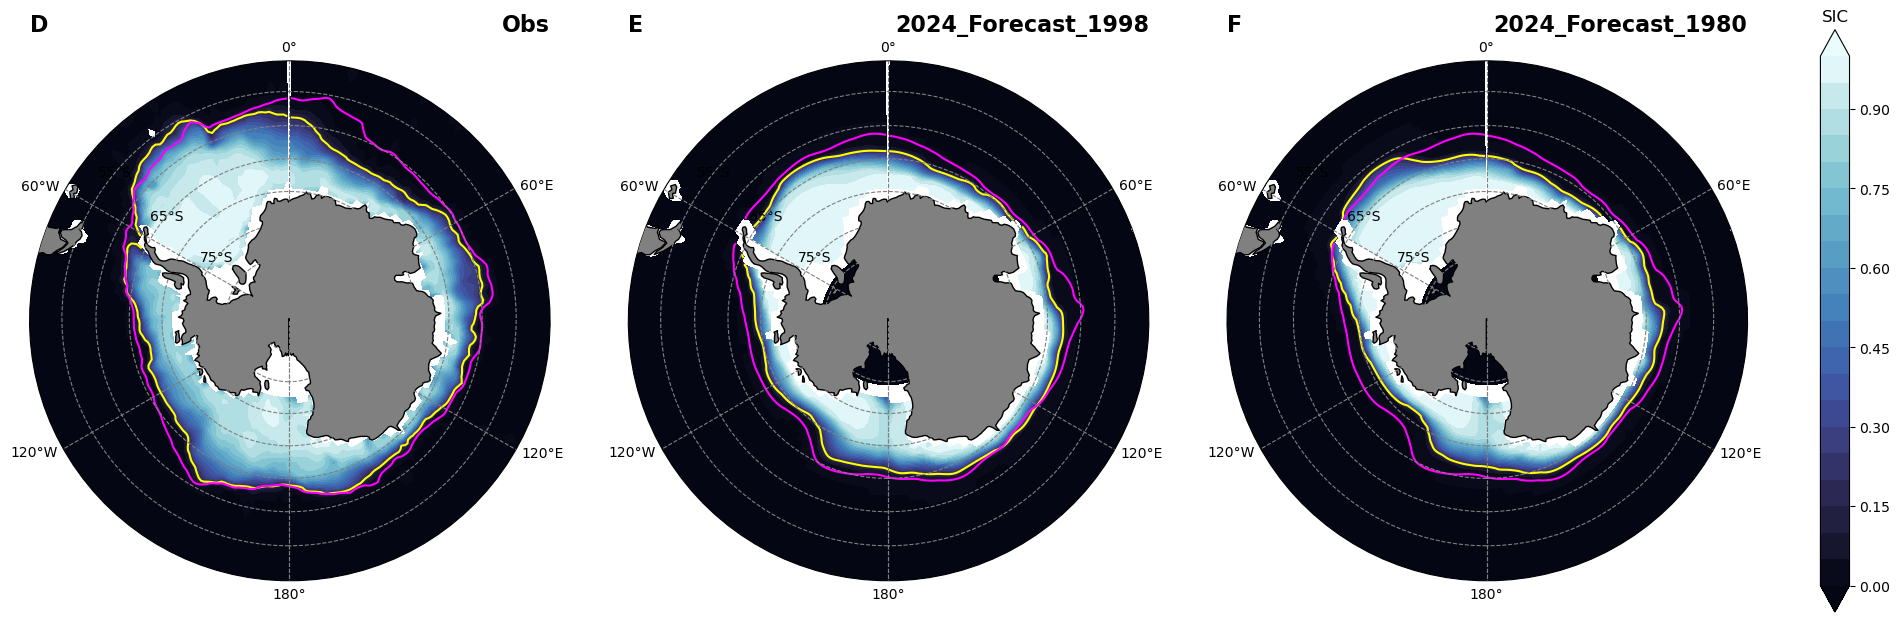

In [21]:
save_info = {
    "save": True,
    "path": "figures/jja_2024_sic_analysis",
    "dpi": 400,
}

cmap_info = {
    "cmap": cmocean.cm.ice, 
    "units": "SIC",
    "shared": True,
    "levels":  np.arange(0, 1.05, .05),
}
obs_ice_2024 = {
    "ds": nsidc_ice.resample(time=SEASON).mean(dim="time").sel(time=SEASON_TIME).squeeze(),
    "edge": nsidc_ice.resample(time=SEASON).mean(dim="time").sel(time=SEASON_TIME).squeeze(),
    "edge_clim": nsidc_ice_clim.resample(time=SEASON).mean(dim="time").isel(time=2).squeeze(),
    "left_title": "D",
    "title": "Obs",
}
MEM_YEAR = 1998
TIME="2024-06"
cesm2_forecast_1998_mem = {
    "ds": cesm2_ice_ens["aice"].resample(time=SEASON).mean(dim="time").sel(time=SEASON_TIME).sel(year=MEM_YEAR).squeeze(),
    "edge": cesm2_ice_ens["aice"].resample(time=SEASON).mean(dim="time").sel(time=SEASON_TIME).sel(year=MEM_YEAR).squeeze(),
    "edge_clim": cesm2_ice_clim["aice"].resample(time=SEASON).mean(dim="time").isel(time=2).squeeze(), # June
    "left_title": "E",
    "title": "2024_Forecast_1998",
}

MEM_YEAR = 1980
TIME="2024-06"
cesm2_forecast_1980_mem = {
    "ds": cesm2_ice_ens["aice"].resample(time=SEASON).mean(dim="time").sel(time=SEASON_TIME).sel(year=MEM_YEAR).squeeze(),
    "edge": cesm2_ice_ens["aice"].resample(time=SEASON).mean(dim="time").sel(time=SEASON_TIME).sel(year=MEM_YEAR).squeeze(),
    "edge_clim": cesm2_ice_clim["aice"].resample(time=SEASON).mean(dim="time").isel(time=2).squeeze(), # June
    "left_title": "F",
    "title": "2024_Forecast_1980",
}


spatial_obs_plot(
    dfs={
        "obs_ice_2024": obs_ice_2024,
        "cesm2_forecast_1998_mem": cesm2_forecast_1998_mem,
        "cesm2_forecast_1980_mem": cesm2_forecast_1980_mem,
    }, 
    cmap_info=cmap_info,
    save_info=save_info,
)

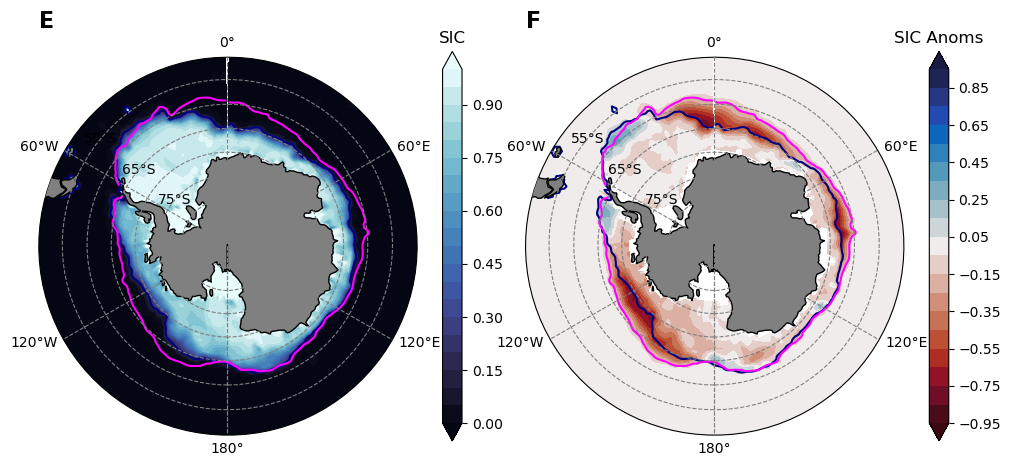

In [8]:

save_info = {
    "save": False,
    "path": "figures/Figure_2024_June_Obs",
    "dpi": 400,
}

cmap_info = {
    "cmap": [cmocean.cm.ice, cmocean.cm.balance_r], 
    "units": ["SIC", "SIC Anoms"],
    "shared": False,
    "levels": [np.arange(0, 1.05, .05), np.arange(-.95, 1.05, .1)],
}
# resample(time=SEASON).mean(dim="time").
obs_ice_2024 = {
    "ds": nsidc_ice.sel(time="2024-06").squeeze(),
    "edge": nsidc_ice.sel(time="2024-06").squeeze(),
    "edge_clim": nsidc_ice_clim.isel(time=5).squeeze(),
    "left_title": "E",
}
obs_ice_2024_anoms = {
    "ds": nsidc_ice_anoms.sel(time="2024-06").squeeze(),
    "edge": nsidc_ice.sel(time="2024-06").squeeze(),
    "edge_clim": nsidc_ice_clim.isel(time=5).squeeze(),
    "left_title": "F",
}

spatial_obs_plot(
    dfs={
        "obs_ice_2024": obs_ice_2024,
        "obs_ice_2024_anoms": obs_ice_2024_anoms,
    }, 
    cmap_info=cmap_info,
    save_info=save_info,
)

# Figure SX - MSE Bias Analysis

In [37]:
# Load SIA/SIE
si_cesm2_ice_ens_2024_regions = load_ensemble(file_name=f"si_regions_CESM_anoms.nc", ens_mems=ENSEMBLE_MEMBERS, ensemble="forecast_ensemble")
si_cesm2_ice_ens_2023_regions = load_ensemble(file_name=f"si_regions_CESM_anoms.nc", ens_mems=ENSEMBLE_MEMBERS, ensemble="persistence_ensemble")
si_cesm2_ice_ens_2024 = load_ensemble(file_name=f"si_CESM_SH_anoms.nc", ens_mems=ENSEMBLE_MEMBERS, ensemble="forecast_ensemble")
si_cesm2_ice_ens_2023 = load_ensemble(file_name=f"si_CESM_SH_anoms.nc", ens_mems=ENSEMBLE_MEMBERS, ensemble="persistence_ensemble")

si_nsidc = xr.open_dataset("/glade/work/zespinosa/Projects/SI-Antarctic/data/si_NSIDC_SH_anoms.nc")
si_regions_nsidc = xr.open_dataset("/glade/work/zespinosa/Projects/SI-Antarctic/data/si_regions_NSIDC_anoms.nc")

si_cesm2 = xr.open_dataset("/glade/work/zespinosa/Projects/SI-Antarctic/data/si_CESM_SH_si-anoms.nc")
si_regions_cesm2 = xr.open_dataset("/glade/work/zespinosa/Projects/SI-Antarctic/data/si_regions_CESM_anoms.nc")

In [38]:
baseline = si_regions_cesm2.sel(time=slice("1980-01", "2020-01")).groupby("time.month").std("time")["sia"]*np.sqrt(2)
baseline

<xarray.DataArray 'sia' (month: 12, region: 6)>
array([[0.17286909, 0.11940576, 0.08564147, 0.22537432, 0.10826678,
        0.04959731],
       [0.0450233 , 0.0365445 , 0.07589032, 0.23862712, 0.04394015,
        0.01239131],
       [0.0683019 , 0.03897287, 0.07183881, 0.2876207 , 0.04537651,
        0.0140289 ],
       [0.2417014 , 0.1116743 , 0.08672043, 0.33049789, 0.12644332,
        0.08876041],
       [0.31334583, 0.20261761, 0.11741149, 0.33692172, 0.17841537,
        0.19995647],
       [0.29745724, 0.23178755, 0.17940971, 0.33916497, 0.21112552,
        0.21969741],
       [0.28005003, 0.22391581, 0.17844895, 0.32725945, 0.22415051,
        0.22337794],
       [0.26323015, 0.25072583, 0.14913862, 0.30552355, 0.20179859,
        0.26158245],
       [0.29802167, 0.2591171 , 0.15448592, 0.26613484, 0.21327441,
        0.25818146],
       [0.28718255, 0.27947455, 0.15837853, 0.30593659, 0.21875202,
        0.2640751 ],
       [0.25894429, 0.28436919, 0.16366256, 0.28890738, 0.23929497,
        0.27675535],
       [0.30921312, 0.2598739 , 0.12179339, 0.25693646, 0.21737412,
        0.18296233]])
Coordinates:
  * region   (region) object 'ross' 'amundsen' ... 'south_west_pacific'
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12

In [39]:
cesm2_jja_2023_regions = si_cesm2_ice_ens_2023_regions.resample(time=SEASON).mean(dim="time").mean("year").sel(time="2023-06").sia
nsidc_jja_2023_regions = si_regions_nsidc.resample(time=SEASON).mean(dim="time").sel(time="2023-06").sia
cesm2_truth_jja_2023_regions = si_regions_cesm2.resample(time=SEASON).mean(dim="time").sel(time="2023-06").sia

In [48]:
LEGEND_LABELS = ['_', '_', "Ross", "Amundsen (AM)", "Bellingshausen (BS)", "Weddell (WE)", "South Indian (SI)", "South West Pacific (SWP)"]

START_DATE = "2023-01-01"
END_DATE = "2023-08-31"
TIME_STEP = 6
colors = ['#d1e5f0','#67a9cf','#2166ac', '#fddbc7', '#ef8a62', '#b2182b']
SI_METRIC = 'sia' 
SI_METRIC_LABEL = 'Sea Ice Area' #'Sea Ice Area'

plot_params = {
    "time_range": slice(START_DATE, END_DATE),
    "ticklabels": np.arange(START_DATE, END_DATE, TIME_STEP, dtype="datetime64[M]"),
    "save_name": "Regional_RMSE_2023_vsNudge",
}

def rmse(x, y):
    return np.sqrt((x - y)**2)

def plot_regional_mse(
    si_cesm_region: xr.DataArray, 
    si_cesm_total: xr.DataArray, 
    si_nsidc_region: xr.DataArray, 
    si_nsidc_total: xr.DataArray,
    si_cesm_truth_region: xr.DataArray,
    si_cesm_truth_total: xr.DataArray,
    baseline: xr.DataArray,
    plot_params: dict = plot_params,
    cesm2_jja_2023_regions: xr.DataArray = cesm2_jja_2023_regions,
    nsidc_jja_2023_regions: xr.DataArray = nsidc_jja_2023_regions,
) -> None:
    # 
    fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(20, 12))
    axs = axs.flatten()
    for i, region in enumerate(si_cesm_region.region.values):
        rmse_region_nsidc = rmse(si_cesm_region.sel(region=region).values, si_nsidc_region.sel(region=region).values)
        rmse_region_cesm = rmse(si_cesm_region.sel(region=region).values, si_cesm_truth_region.sel(region=region).values)
        for j, yr in enumerate(si_cesm_region.year):
            axs[i].plot(si_cesm_region.time, rmse_region_nsidc.T[:,j], color=colors[1]) #si_cesm_region.region.values.tolist().index(region)])
            # axs[i].plot(si_cesm_region.time, rmse_region_cesm.T[:,j], linestyle="dashed", color=colors[4]) #si_cesm_region.region.values.tolist().index(region)])

        # plot baseline
        # axs[i].plot(si_cesm_region.time, baseline.sel(region=region, month=np.arange(1, 1+len(si_cesm_region.time))).values, color="yellow", linestyle="dashed")
        
        axs[i].plot(si_cesm_region.time, np.mean(rmse_region_nsidc.T, axis=1), color="black")
        # axs[i].plot(si_cesm_region.time, np.mean(rmse_region_cesm.T, axis=1), color="black", linestyle="dashed")
        
        rmse_truth = rmse(si_cesm_truth_region.sel(region=region).values, si_nsidc_region.sel(region=region).values)
        axs[i].plot(si_cesm_region.time, rmse_truth, color="maroon", linewidth=2)

        axs[i].grid()

        region_title = region.replace("_", " ")
        region_title = region_title[0].upper() + region_title[1:]
        axs[i].set_title(f"{region_title}", fontweight="bold", loc="right", fontsize=14)
        axs[i].set_ylabel("RMSE")
        axs[i].set_ylim(0, 1)

        cesm_nudge_ens = np.around(cesm2_jja_2023_regions.sel(region=region).values[0],2)
        cesm_truth_nudge = np.around(cesm2_truth_jja_2023_regions.sel(region=region).values[0],2)
        nsidc_jja = np.around(nsidc_jja_2023_regions.sel(region=region).values[0],2)

        # In the upper left corner add text with the RMSE for the region
        # Put text in a box:
        axs[i].text(0.05, 0.75, 
            f"NSIDC: {nsidc_jja}\n"
            f"CESM-NUDGE: {cesm_truth_nudge}\n"
            f"CESM-NUDGE-ENS: {cesm_nudge_ens}", 
            bbox=dict(facecolor='lightgray', edgecolor='black', boxstyle='round,pad=0.5'), 
            transform=axs[i].transAxes, fontsize=12, fontweight="bold")
        
        # axs[i].text(0.05, 0.8, f"CESM-NUDGE: {cesm_truth_nudge}", transform=axs[i].transAxes, fontsize=12, fontweight="bold")
        # axs[i].text(0.05, 0.7, f"CESM-NUDGE-ENS: {cesm_nudge_ens}", transform=axs[i].transAxes, fontsize=12, fontweight="bold")
        

    plt.suptitle("Regional RMSE REFORECAST-2023", fontweight="bold", fontsize=16)

    save_name = plot_params["save_name"]
    plt.savefig(f"figures/{save_name}.pdf", dpi=400, bbox_inches="tight")
    plt.savefig(f"figures/{save_name}.png", dpi=400, bbox_inches="tight")

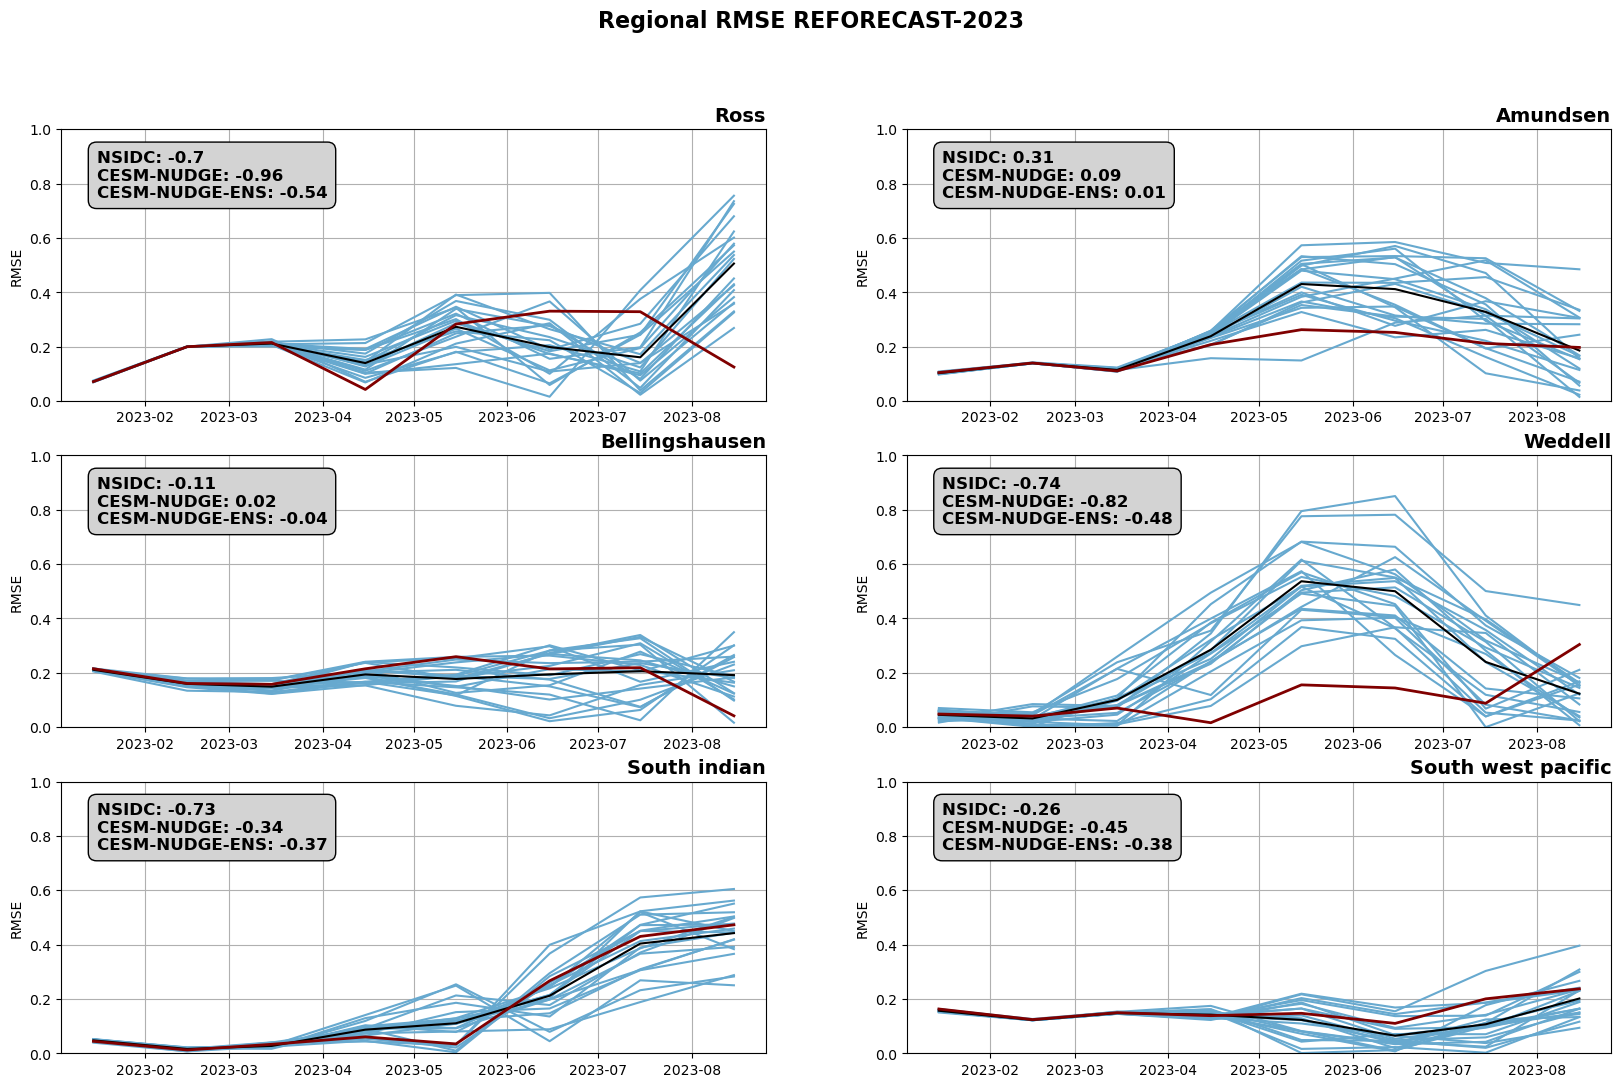

In [49]:
plot_params = {
    "time_range": slice(START_DATE, END_DATE),
    "ticklabels": np.arange(START_DATE, END_DATE, TIME_STEP, dtype="datetime64[M]"),
    "save_name": "Regional_RMSE_2023",
}
plot_regional_mse(
    si_cesm_region=si_cesm2_ice_ens_2023_regions[SI_METRIC].sel(time=plot_params["time_range"]),
    si_cesm_total=si_cesm2_ice_ens_2023[SI_METRIC].sel(time=plot_params["time_range"]),
    si_nsidc_region=si_regions_nsidc[SI_METRIC].sel(time=plot_params["time_range"]),
    si_nsidc_total=si_nsidc[SI_METRIC].sel(time=plot_params["time_range"]),
    si_cesm_truth_region=si_regions_cesm2[SI_METRIC].sel(time=plot_params["time_range"]),
    si_cesm_truth_total=si_cesm2[SI_METRIC].sel(time=plot_params["time_range"]),
    baseline=baseline,
)